# Regresión Bayesiana con Inferencia Variacional

**Objetivo**: Implementar regresión bayesiana usando inferencia variacional para aproximar la distribución posterior.

## 1. Generación de Datos
 **Modelo verdadero**:
$ y(x) = \sin(2\pi x) $
 **Datos observados** (con ruido gaussiano):
$ t = y(x) + \epsilon,\quad \epsilon \sim \mathcal{N}(0, \beta^{-1}) $ donde $(\beta = 1/\sigma^2 = 100)
$

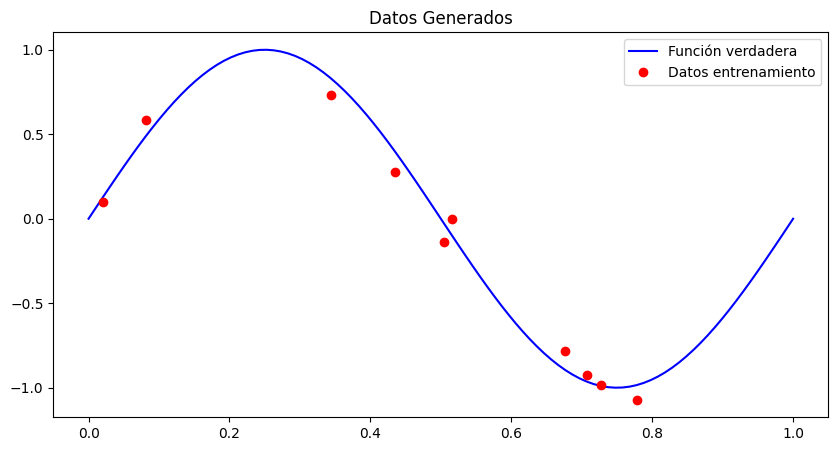

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración reproducible
np.random.seed(10**4)

# Parámetros del modelo
N_tot = 100
sigma2 = 0.01
beta = 1/sigma2
betaInv = 1/beta

# Generar datos
x_tot = np.linspace(0, 1, num=N_tot)
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(betaInv)*np.random.randn(N_tot)

# Selección de datos de entrenamiento
N = 10
index = np.random.permutation(N_tot)
t = t_tot[index[0:N]]
x = x_tot[index[0:N]]

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x, t, '.r', markersize=12, label='Datos entrenamiento')
ax.set_title('Datos Generados')
ax.legend()
plt.show()

## 2. Funciones de Base Radial (RBF)
 **Bases usadas**:
$[ \phi_j(x) = \exp\left(-\frac{(x-\mu_j)^2}{2s^2}\right) ]$

 - $(M=10)$ bases $(9 RBF + 1 bias)$
 - Centros $(\mu_j)$ espaciados uniformemente
 - Ancho $(s^2 = 0.05 \times \text{espaciado entre centros})$

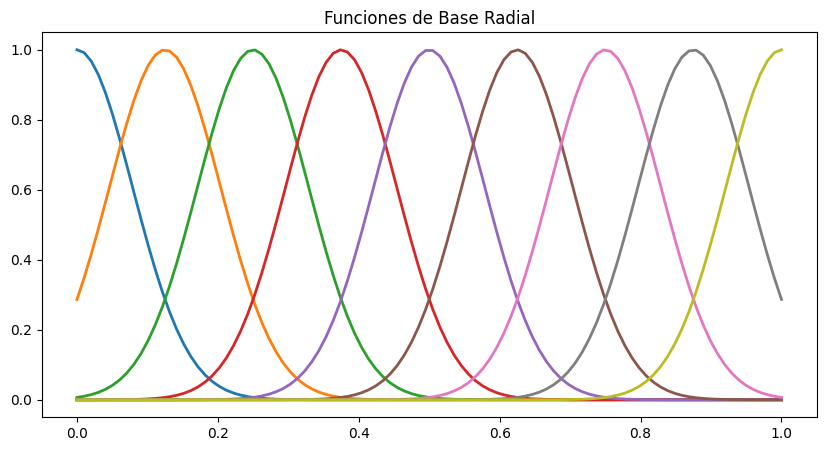

In [2]:
M = 10
mu = np.linspace(0, 1, M-1)
s2 = 0.05*np.diff(mu)[0]

# Matriz de diseño
PHI_tot = np.ones((N_tot, M))
for i in range(1, M):
    PHI_tot[:, i] = np.exp(-(x_tot - mu[i-1])**2/(2*s2))

# Visualización de bases
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_tot, PHI_tot[:, 1:], linewidth=2)
ax.set_title('Funciones de Base Radial')
plt.show()

## 3. Inferencia Variacional 🔄
**Modelo jerárquico**:
$[
 \begin{aligned}
 p(t|w,\beta) &= \mathcal{N}(t|\Phi w, \beta^{-1}I) \\
 p(w|\alpha) &= \mathcal{N}(w|0, \alpha^{-1}I) \\
 p(\alpha) &= \text{Gamma}(\alpha|a_0,b_0)
 \end{aligned}
]$

**Aproximación variacional**:
$[ q(w,\alpha) = q(w)q(\alpha) ]$

### 3.1 Actualización de Parámetros Variacionales
**Para $(q(\alpha))$**:
$[
 q(\alpha) = \text{Gamma}(\alpha|a_N,b_N)
]$
$[
 a_N = a_0 + \frac{M}{2},\quad b_N = b_0 + \frac{1}{2}\mathbb{E}[w^Tw]
]$

**Para $(q(w))$**:
$[
 q(w) = \mathcal{N}(w|m_N,S_N)
]$
$[
 S_N^{-1} = \mathbb{E}[\alpha]I + \beta\Phi^T\Phi
]$
$[
 m_N = \beta S_N \Phi^T t
]$

In [3]:
# Configuración inicial variacional
niters = 20
a0, b0 = 1, 1  # Hiperparámetros para q(alpha)
E_alpha = 1.0    # Valor inicial para E[alpha]
E_wT_w = 1.0     # Valor inicial para E[w^T w]

# Matriz de diseño para entrenamiento
PHI = np.ones((N, M))
for i in range(1, M):
    PHI[:, i] = np.exp(-(x - mu[i-1])**2/(2*s2))

# Almacenamiento de valores
E_alphav = np.zeros(niters)

# Optimización variacional
for i in range(niters):
    # Actualizar q(alpha)
    aN = a0 + M/2
    bN = b0 + 0.5*E_wT_w
    E_alpha = aN / bN  # E[alpha] para q(alpha)

    # Actualizar q(w)
    SNInv = E_alpha*np.eye(M) + beta*(PHI.T @ PHI)
    SN = np.linalg.solve(SNInv, np.eye(M))
    mN = beta * SN @ PHI.T @ t[:, np.newaxis]

    # Calcular E[w^T w] = tr(m_N m_N^T + S_N)
    E_wT_w = np.trace(mN @ mN.T + SN)

    E_alphav[i] = E_alpha

### 3.2 Convergencia de los Parámetros
 Visualización de la evolución de $(\mathbb{E}[\alpha])$


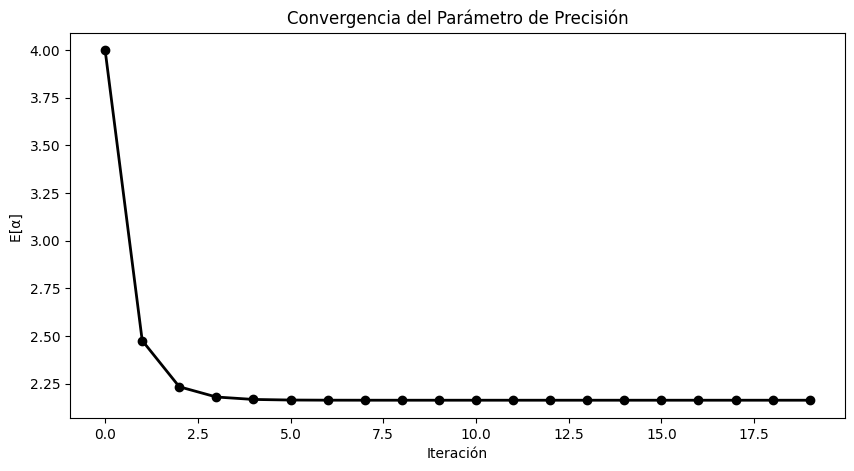

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(E_alphav, 'k-o', linewidth=2)
ax.set_xlabel('Iteración')
ax.set_ylabel('E[α] ')
ax.set_title('Convergencia del Parámetro de Precisión')
plt.show()

## 4. Distribución Predictiva
 **Media predictiva**:
$[ \mathbb{E}[t^*|x^*] = \Phi(x^*)m_N ]$

 **Varianza predictiva**:
$[ \text{Var}[t^*|x^*] = \beta^{-1} + \Phi(x^*)S_N\Phi(x^*)^T ]$

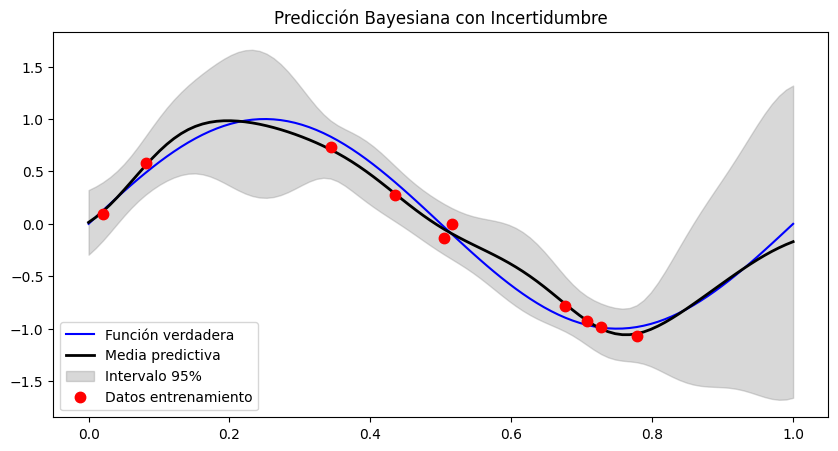

In [7]:
# Cálculo de predicciones
mpred = PHI_tot @ mN
vpred = betaInv + np.diag(PHI_tot @ SN @ PHI_tot.T)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x_tot, mpred, 'k', linewidth=2, label='Media predictiva')
ax.fill_between(x_tot,
                mpred.flatten() - 2*np.sqrt(vpred),
                mpred.flatten() + 2*np.sqrt(vpred),
                color='gray', alpha=0.3, label='Intervalo 95%')
ax.plot(x, t, '.r', markersize=15, label='Datos entrenamiento')
ax.set_title('Predicción Bayesiana con Incertidumbre')
ax.legend()
plt.show()

## 5. Ventajas de la Inferencia Variacional

1. **Eficiencia computacional**: Solo 20 iteraciones vs métodos MCMC
2. **Control de complejidad**: Auto-ajuste de $(\alpha)$ previene sobreajuste
3. **Incertidumbre cuantificada**: Intervalos predictivos confiables

 **Comparación con Type II ML** (código comentado):
 - VI mantiene distribuciones completas vs estimación puntual
 - Más robusto en muestras pequeñas

## 6. Posibles Mejoras
- Optimizar número de bases $(M)$
- Experimentar con diferentes inicializaciones
- Añadir selección automática de hiperparámetros $(a_0,b_0)$